# Notebook 04 . Analyse semantique (LDA, BERTopic, Embeddings, FrameAxis)

## Ce qu'on fait ici

On explore la **structure thematique** des discours VSS a l'Assemblee Nationale avec plusieurs familles de methodes :

**Partie A . Topic modeling LDA classique** : decouverte non supervisee des thematiques latentes.
La LDA (Blei, Ng & Jordan, 2003) repose sur un modele generatif bag-of-words et ne capture
ni l'ordre des mots ni les relations syntaxiques. Elle reste utile comme baseline mais presente
des limites connues pour les corpus politiques ou les memes mots apparaissent dans des frames opposes.

**Partie A2 . GuidedLDA** : approche semi-supervisee (Jagarlamudi, Daume III & Udupa, 2012)
avec des seed words pour guider l'emergence d'un topic immigration/identite.

**Partie A3 . BERTopic** : alternative neuronale a la LDA (Grootendorst, 2022). BERTopic
combine des sentence embeddings pre-entraines, un clustering HDBSCAN, et une representation
par c-TF-IDF. Contrairement a la LDA, elle preserve la semantique distributionnelle et
produit des topics contextualises. C'est la methode de reference en 2024-2025 pour le
topic modeling de corpus politiques (Mu, Bontcheva & Aletras, 2024).

**Partie B . Embeddings Sentence-CamemBERT** : chaque discours est transforme en vecteur
numerique pour mesurer la similarite semantique entre blocs au fil du temps.

**Partie C . FrameAxis** : methode inspiree de Kwak et al. (2021) pour mesurer la position
de chaque prise de parole sur un axe semantique bipolaire (immigres-agresseurs vs. immigres-victimes).
Contrairement a la similarite cosinus avec un concept unique, FrameAxis capture la **direction**
du cadrage, pas seulement la proximite thematique.

### Choix methodologiques

- Pour la LDA, on selectionne le modele optimal par le score **c_v** (Roder et al., 2015),
  qui mesure la coherence externe via des word embeddings, plutot que u_mass (coherence
  interne par co-occurrence), car c_v est mieux correle avec le jugement humain.
- Pour les embeddings, on utilise **Sentence-CamemBERT-Large** (La Javaness, 2022),
  un CamemBERT fine-tune avec un reseau siamois (architecture Sentence-BERT, Reimers & Gurevych, 2019)
  sur le dataset STSb francais.

## Partie A . Topic Modeling LDA

### A.1 Imports et chargement

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import re, os, pickle, warnings
from tqdm import tqdm

from gensim import corpora, models
from gensim.models import LdaModel, LdaMulticore, Phrases
from gensim.models.coherencemodel import CoherenceModel

import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import FrenchStemmer
nltk.download('stopwords', quiet=True)

warnings.filterwarnings('ignore')
stemmer = FrenchStemmer()

import matplotlib.pyplot as plt
import matplotlib as mpl

PALETTE_PASTEL = ["#A8D8EA", "#AA96DA", "#FCBAD3", "#FFFFD2", "#B5EAD7",
                  "#C7CEEA", "#FFB7B2", "#E2F0CB", "#FFDAC1", "#B5B8FF"]
COULEURS_BLOCS = {
    "Extrême Droite": "#E88D9A", "Droite Traditionnelle": "#7BAFD4",
    "Centre": "#F2CC8F", "Gauche Modérée": "#81B29A", "Gauche Radicale": "#D4A5A5",
}
ORDRE_BLOCS = ["Extrême Droite", "Droite Traditionnelle", "Centre", "Gauche Modérée", "Gauche Radicale"]

plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11, 'font.weight': 'light',
    'axes.titlesize': 13, 'axes.titleweight': 'normal',
    'axes.labelsize': 11, 'axes.labelweight': 'light',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.color': '#DDDDDD',
    'legend.frameon': False, 'legend.fontsize': 9,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'xtick.color': '#333333', 'ytick.color': '#333333', 'text.color': '#222222',
})


# Chargement
chemin_propre = "/home/onyxia/work/projet_eco_socio/df_vss_propre.pkl"
if not os.path.exists(chemin_propre):
    chemin_propre = "/home/onyxia/work/projet_eco_socio/dataframes/df_vss_propre.pkl"
df_vss = pd.read_pickle(chemin_propre)
df_vss['date'] = pd.to_datetime(df_vss['date'])
df_blocs = df_vss.dropna(subset=['bloc']).copy()
print(f"{len(df_blocs)} prises de parole chargées ({df_blocs['bloc'].nunique()} blocs).")

7815 prises de parole chargées (5 blocs).


### A.2 Pré-traitement

Le nettoyage est l'étape qui a le plus d'impact sur la qualité des topics. On retire :
- Le **bruit parlementaire** (monsieur, madame, président, amendement, article, commission...)
- Les **mots-clés VSS** eux-memes (sinon ils dominent tous les topics, puisqu'on a filtré le corpus par ces mots)
- On applique le **stemming** (Snowball) et on détecte les **bigrammes** fréquents

In [2]:
stop_words = set(stopwords.words('french'))

# Bruit parlementaire
bruit = {
    "monsieur", "madame", "président", "présidente", "ministre",
    "député", "députée", "députés", "collègue", "collègues",
    "secrétaire", "rapporteur", "rapporteure", "orateur",
    "amendement", "amendements", "article", "articles", "alinéa",
    "projet", "proposition", "loi", "texte", "vote", "voter",
    "adopter", "adopté", "adoptée", "séance", "commission",
    "discussion", "débat", "examen", "lecture", "scrutin",
    "hémicycle", "assemblée", "nationale", "gouvernement",
    "groupe", "banc", "bancs", "applaudissements",
    "demander", "proposer", "souhaiter", "permettre", "falloir",
    "devoir", "pouvoir", "vouloir", "savoir", "croire",
    "penser", "dire", "faire", "être", "avoir", "aller",
    "plus", "très", "bien", "tout", "tous", "toute", "toutes",
    "aussi", "donc", "encore", "vraiment", "évidemment",
    "également", "simplement", "effectivement", "certainement",
    "aujourd", "hui", "ici", "puis", "enfin", "ainsi",
    "premier", "première", "deux", "trois", "million", "milliard", "euro", "euros",
}

# Mots-clés VSS a retirer (biais circulaire)
mots_vss = {
    "viol", "viols", "violences", "violence", "sexuel", "sexuelle", "sexuels", "sexuelles",
    "sexiste", "sexistes", "harcèlement", "agression", "agressions", "conjugal", "conjugale",
    "féminicide", "féminicides", "inceste", "outrage", "discrimination", "genre", "sexe",
    "avortement", "ivg", "consentement", "stéréotype", "prostitu", "prostitution",
    "pédocriminalité", "pédophilie", "misogyne", "misogynie", "mutilation", "mutilations",
}

# RESIDUS STEMMES qui polluent les topics (identifiés après inspection des résultats)
# Ce sont des mots trop génériques qui apparaissent dans TOUS les topics
residus_stemmes = {
    # Pronoms et déterminants stemmés
    "cel", "comm", "autr", "peut", "fait", "don", "dit",
    "quelqu", "plusieur", "certain", "non", "san", "del",
    "vis", "mme", "leur", "notr", "votr", "chacun",
    # Bruit procédural stemmé
    "applaud", "exclam", "adopt", "propos", "vot",
    "séanc", "parol", "banc", "lfi_nup", "nfp", "rn_lr",
    # Verbes trop fréquents stemmés
    "permet", "demand", "propos", "souhait", "concern",
    "prévoi", "exist", "trait", "rend", "donn", "pris",
    "mis", "pren", "vien", "pass", "port", "rest",
    # Adjectifs/adverbes génériques stemmés
    "grand", "petit", "important", "vraiement", "particuli",
    "nécessair", "aujourd", "dernier", "prochain",
    # Noms trop génériques
    "franc", "pay", "état", "républ", "polit", "social",
    "person", "ann", "question", "rapport", "cadre",
    "mesur", "moyen", "disposit", "situat", "system",
    "maniér", "lieu", "form", "part", "term",
    "sujet", "problèm", "matiér", "domain",
}

stop_words.update(bruit)
stop_words.update(mots_vss)
stop_words.update(residus_stemmes)

def tokeniser(texte):
    texte = re.sub(r'[^a-zàâäéèêëïîôùûüÿçœæ\s]', ' ', str(texte).lower())
    return [stemmer.stem(m) for m in texte.split() if m not in stop_words and len(m) > 2]

df_blocs['tokens'] = df_blocs['texte'].apply(tokeniser)
df_blocs = df_blocs[df_blocs['tokens'].apply(len) > 3].copy()

bigram_model = Phrases(df_blocs['tokens'].tolist(), min_count=10, threshold=50)
df_blocs['tokens_bi'] = df_blocs['tokens'].apply(lambda d: bigram_model.freeze()[d])

textes_lda = df_blocs['tokens_bi'].tolist()
dico = corpora.Dictionary(textes_lda)
dico.filter_extremes(no_below=10, no_above=0.3, keep_n=5000)
corpus = [dico.doc2bow(d) for d in textes_lda]

print(f"{len(corpus)} documents, {len(dico)} termes dans le dictionnaire.")
print(f"Stopwords totaux : {len(stop_words)}")

7676 documents, 5000 termes dans le dictionnaire.
Stopwords totaux : 357


##### A.3 Grid search : nombre de topics et hyperparametres

On teste k de 3 a 25, avec 4 combinaisons alpha x eta, et on évalue chaque modèle
par la cohérence u_mass et c_v. Les résultats sont mis en cache pour ne pas refaire
cette étape couteuse a chaque exécution.

In [20]:
DOSSIER_DATAFRAMES = "/home/onyxia/work/projet_eco_socio/dataframes"
os.makedirs(DOSSIER_DATAFRAMES, exist_ok=True)

chemin_grid = os.path.join(DOSSIER_DATAFRAMES, "lda_grid_search_results.pkl")
chemin_lda_old = os.path.join(DOSSIER_DATAFRAMES, "lda_best_model.pkl")

if os.path.exists(chemin_grid): os.remove(chemin_grid); print("Cache grid supprimé.")
if os.path.exists(chemin_lda_old): os.remove(chemin_lda_old); print("Cache modèle supprimé.")

if os.path.exists(chemin_grid):
    with open(chemin_grid, 'rb') as f:
        grid_results = pickle.load(f)
    print(f"Grid search chargée depuis le cache ({len(grid_results)} configs testées).")
else:
    print("Grid search en cours (10-30 min)...\n")
    topics_range = [3, 5, 7, 10, 13, 15, 20, 25]
    grid_results = []
    total = len(topics_range) * 4
    idx = 0
    for k in topics_range:
        for alpha in ['symmetric', 'asymmetric']:
            for eta in ['symmetric', 'auto']:
                idx += 1
                print(f"  [{idx}/{total}] k={k}, alpha={alpha}, eta={eta}...", end=" ")
                try:
                    m = LdaMulticore(corpus=corpus, id2word=dico, num_topics=k,
                                     alpha=alpha, eta=eta, passes=15, iterations=200,
                                     random_state=42, chunksize=500, per_word_topics=True)
                    s_u = CoherenceModel(model=m, corpus=corpus, dictionary=dico, coherence='u_mass').get_coherence()
                    s_c = CoherenceModel(model=m, texts=textes_lda, dictionary=dico, coherence='c_v').get_coherence()
                    p = m.log_perplexity(corpus)
                    grid_results.append({'k':k,'alpha':alpha,'eta':eta,'u_mass':s_u,'c_v':s_c,'perplexity':p})
                    print(f"u_mass={s_u:.4f}, c_v={s_c:.4f}")
                except Exception as e:
                    print(f"ERREUR: {e}")
    with open(chemin_grid, 'wb') as f:
        pickle.dump(grid_results, f)
    print(f"\nSauvegardé dans {chemin_grid}")

INFO:gensim.models.ldamodel:using symmetric alpha at 0.3333333333333333
INFO:gensim.models.ldamodel:using symmetric eta at 0.3333333333333333
INFO:gensim.models.ldamodel:using serial LDA version on this node
INFO:gensim.models.ldamulticore:running online LDA training, 3 topics, 15 passes over the supplied corpus of 7676 documents, updating every 35500 documents, evaluating every ~7676 documents, iterating 200x with a convergence threshold of 0.001000
INFO:gensim.models.ldamulticore:training LDA model using 71 processes


Cache grid supprimé.
Cache modèle supprimé.
Grid search en cours (10-30 min)...

  [1/32] k=3, alpha=symmetric, eta=symmetric... 

INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #0 = documents up to #500/7676, outstanding queue size 1
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #1 = documents up to #1000/7676, outstanding queue size 2
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #2 = documents up to #1500/7676, outstanding queue size 3
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #3 = documents up to #2000/7676, outstanding queue size 4
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #4 = documents up to #2500/7676, outstanding queue size 5
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #5 = documents up to #3000/7676, outstanding queue size 6
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #6 = documents up to #3500/7676, outstanding queue size 7
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #7 = documents up to #4000/7676, outstanding queue size 8
I

u_mass=-1.3354, c_v=0.3017
  [2/32] k=3, alpha=symmetric, eta=auto... 

INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #0 = documents up to #500/7676, outstanding queue size 1
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #1 = documents up to #1000/7676, outstanding queue size 2
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #2 = documents up to #1500/7676, outstanding queue size 3
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #3 = documents up to #2000/7676, outstanding queue size 4
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #4 = documents up to #2500/7676, outstanding queue size 5
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #5 = documents up to #3000/7676, outstanding queue size 6
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #6 = documents up to #3500/7676, outstanding queue size 7
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #7 = documents up to #4000/7676, outstanding queue size 8
I

...

u_mass=-1.6516, c_v=0.3320
  [31/32] k=25, alpha=asymmetric, eta=symmetric... 

INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #0 = documents up to #500/7676, outstanding queue size 1
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #1 = documents up to #1000/7676, outstanding queue size 2
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #2 = documents up to #1500/7676, outstanding queue size 3
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #3 = documents up to #2000/7676, outstanding queue size 4
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #4 = documents up to #2500/7676, outstanding queue size 5
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #5 = documents up to #3000/7676, outstanding queue size 6
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #6 = documents up to #3500/7676, outstanding queue size 7
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #7 = documents up to #4000/7676, outstanding queue size 8
I

u_mass=-1.7731, c_v=0.3351
  [32/32] k=25, alpha=asymmetric, eta=auto... 

INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #0 = documents up to #500/7676, outstanding queue size 1
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #1 = documents up to #1000/7676, outstanding queue size 2
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #2 = documents up to #1500/7676, outstanding queue size 3
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #3 = documents up to #2000/7676, outstanding queue size 4
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #4 = documents up to #2500/7676, outstanding queue size 5
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #5 = documents up to #3000/7676, outstanding queue size 6
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #6 = documents up to #3500/7676, outstanding queue size 7
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #7 = documents up to #4000/7676, outstanding queue size 8
I

u_mass=-1.7732, c_v=0.3351

Sauvegardé dans /home/onyxia/work/projet_eco_socio/dataframes/lda_grid_search_results.pkl


### A.4 Visualisation des scores de cohérence

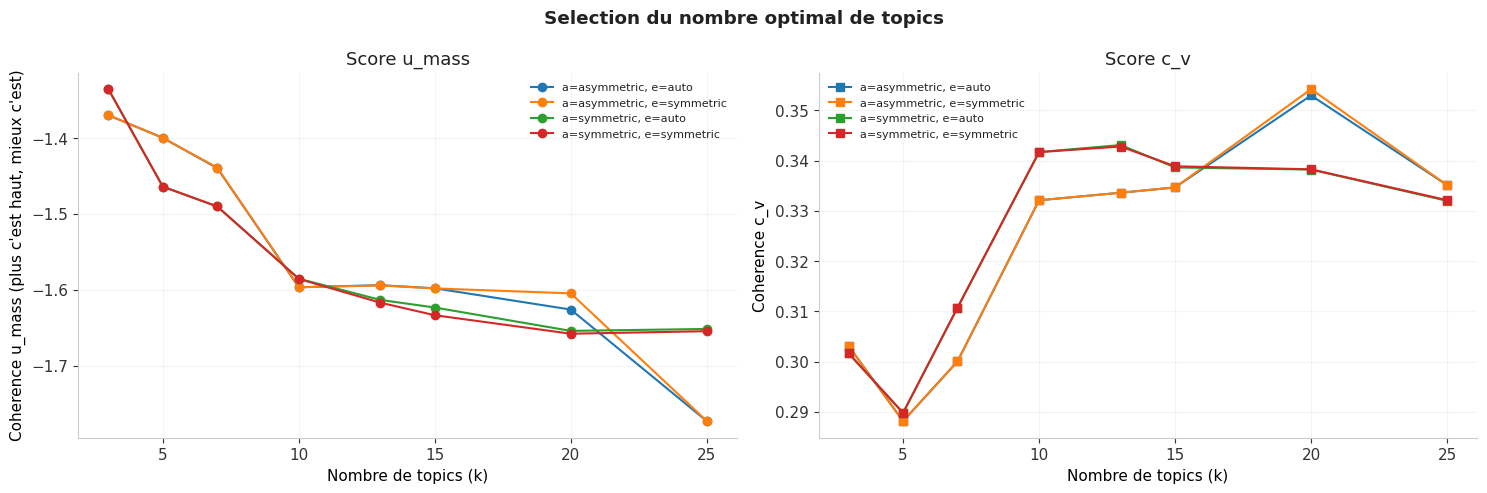


Top 5 par u_mass :
 k      alpha       eta    u_mass      c_v  perplexity
 3  symmetric symmetric -1.335371 0.301657   -7.532106
 3  symmetric      auto -1.335371 0.301657   -7.518234
 3 asymmetric symmetric -1.369673 0.303115   -7.533654
 3 asymmetric      auto -1.369673 0.303115   -7.519735
 5 asymmetric      auto -1.399612 0.288176   -7.519294


In [21]:
df_grid = pd.DataFrame(grid_results)

# Compatibilite avec l'ancien cache (noms de colonnes differents)
if 'coherence_umass' in df_grid.columns and 'u_mass' not in df_grid.columns:
    df_grid = df_grid.rename(columns={'coherence_umass': 'u_mass', 'coherence_cv': 'c_v'})
    print("Colonnes renommees depuis l'ancien format du cache.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for (alpha, eta), grp in df_grid.groupby(['alpha', 'eta']):
    g = grp.sort_values('k')
    axes[0].plot(g['k'], g['u_mass'], marker='o', label=f"a={alpha}, e={eta}", lw=1.5)
    axes[1].plot(g['k'], g['c_v'], marker='s', label=f"a={alpha}, e={eta}", lw=1.5)
axes[0].set_xlabel("Nombre de topics (k)")
axes[0].set_ylabel("Coherence u_mass (plus c'est haut, mieux c'est)")
axes[0].set_title("Score u_mass")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("Nombre de topics (k)")
axes[1].set_ylabel("Coherence c_v")
axes[1].set_title("Score c_v")
axes[1].legend(fontsize=8)
plt.suptitle("Selection du nombre optimal de topics", fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 par u_mass :")
print(df_grid.sort_values('u_mass', ascending=False).head(5).to_string(index=False))

### A.5 Selection du modele optimal

On ne retient pas le k=3 meme s'il a le meilleur score de coherence. Avec seulement
3 topics, on ne peut pas distinguer un signal identitaire fin dans un corpus thematiquement
riche (VSS couvre la PMA, le harcelement au travail, les violences conjugales, l'IVG, etc.).

On impose un **plancher a 10 topics** et on selectionne la meilleure configuration au-dessus.

> **Choix de la metrique** : on utilise **c_v** (Roder, Both & Hinneburg, 2015) plutot que
> u_mass (Mimno et al., 2011) pour la selection finale. La coherence c_v, basee sur des
> co-occurrences dans une fenetre glissante et des similarites de word embeddings, est
> mieux correlee avec le jugement humain (Roder et al., 2015, Table 3). La coherence u_mass,
> purement intrinsèque (co-occurrence dans le corpus), ne mesure pas si les topics capturent
> les distinctions politiques pertinentes pour notre analyse.

In [22]:
# Compatibilite noms de colonnes
if 'coherence_umass' in df_grid.columns and 'u_mass' not in df_grid.columns:
    df_grid = df_grid.rename(columns={'coherence_umass': 'u_mass', 'coherence_cv': 'c_v'})

# Filtrer : on garde seulement k >= 10
df_filtered = df_grid[df_grid['k'] >= 10].copy()
best = df_filtered.sort_values('c_v', ascending=False).iloc[0]
best_k = int(best['k'])

print(f"Meilleure config avec k >= 10 :")
print(f"  k={best_k}, alpha={best['alpha']}, eta={best['eta']}")
print(f"  c_v={best['c_v']:.4f}, u_mass={best['u_mass']:.4f}")

best_global = df_grid.sort_values('c_v', ascending=False).iloc[0]
print(f"\n(Pour info, le meilleur global est k={int(best_global['k'])} avec u_mass={best_global['u_mass']:.4f})")
if int(best_global['k']) < 10:
    print(f"On ne le retient pas car {int(best_global['k'])} topics est trop grossier pour notre analyse.)")

chemin_lda = os.path.join(DOSSIER_DATAFRAMES, "lda_best_model.pkl")
chemin_dict = os.path.join(DOSSIER_DATAFRAMES, "lda_best_dict.pkl")

# Verification : si le modele en cache a un k different de best_k, on le supprime
if os.path.exists(chemin_lda):
    try:
        from gensim.models import LdaModel as _LDA
        _cached = _LDA.load(chemin_lda)
        if _cached.num_topics != best_k:
            print(f"\nLe modele en cache a {_cached.num_topics} topics, mais on veut {best_k}.")
            print("Suppression du cache pour reentrainer...")
            os.remove(chemin_lda)
            if os.path.exists(chemin_dict):
                os.remove(chemin_dict)
            # Supprimer aussi les fichiers annexes de gensim
            for ext in ['.state', '.id2word', '.expElogbeta.npy']:
                p = chemin_lda + ext
                if os.path.exists(p): os.remove(p)
        del _cached
    except Exception:
        pass

if os.path.exists(chemin_lda):
    lda_best = LdaModel.load(chemin_lda)
    dico = corpora.Dictionary.load(chemin_dict)
    corpus = [dico.doc2bow(d) for d in textes_lda]
    print(f"Modele LDA charge depuis le cache (k={lda_best.num_topics}).")
else:
    print(f"\nEntrainement du modele final (k={best_k}, passes=30, iterations=400)...")
    lda_best = LdaMulticore(corpus=corpus, id2word=dico, num_topics=best_k,
                             alpha=best['alpha'], eta=best['eta'],
                             passes=30, iterations=400, random_state=42,
                             chunksize=500, per_word_topics=True)
    lda_best.save(chemin_lda)
    dico.save(chemin_dict)
    print(f"Sauvegarde (k={best_k}).")

INFO:gensim.models.ldamodel:using symmetric alpha at 0.1
INFO:gensim.models.ldamodel:using serial LDA version on this node
INFO:gensim.models.ldamulticore:running online LDA training, 10 topics, 30 passes over the supplied corpus of 7676 documents, updating every 35500 documents, evaluating every ~7676 documents, iterating 400x with a convergence threshold of 0.001000
INFO:gensim.models.ldamulticore:training LDA model using 71 processes


Meilleure config avec k >= 10 :
  k=10, alpha=symmetric, eta=auto
  u_mass=-1.5854, c_v=0.3417

(Pour info, le meilleur global est k=3 avec u_mass=-1.3354)
On ne le retient pas car 3 topics est trop grossier pour notre analyse.)

Entrainement du modele final (k=10, passes=30, iterations=400)...


INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #0 = documents up to #500/7676, outstanding queue size 1
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #1 = documents up to #1000/7676, outstanding queue size 2
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #2 = documents up to #1500/7676, outstanding queue size 3
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #3 = documents up to #2000/7676, outstanding queue size 4
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #4 = documents up to #2500/7676, outstanding queue size 5
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #5 = documents up to #3000/7676, outstanding queue size 6
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #6 = documents up to #3500/7676, outstanding queue size 7
INFO:gensim.models.ldamulticore:PROGRESS: pass 0, dispatched chunk #7 = documents up to #4000/7676, outstanding queue size 8
I

Sauvegarde (k=10).


### A.6 Inspection des topics

In [40]:
# Dictionnaire des labels que nous avons définis
topic_labels = {
    0: "Égalité professionnelle et lutte contre les discriminations au travail",
    1: "Droits de la famille, parentalité, adoption et PMA",
    2: "Handicap, droits sociaux et d'inclusion",
    3: "Santé reproductive, IVG et droits des femmes",
    4: "Bioéthique, dons et contrôles",
    5: "Principes républicains, libertés fondamentales et discriminations",
    6: "Débats parlementaires (Ambiance, LFI-NUPES)",
    7: "Justice pénale, protection des mineurs et infractions",
    8: "Lutte contre les violences conjugales et protection des victimes",
    9: "Éducation, milieu scolaire et jeunesse"
}

print("=" * 90)
print(f"TOPICS (k={lda_best.num_topics})")
print("=" * 90)

# Calcul de la cohérence
tc = CoherenceModel(model=lda_best, texts=textes_lda, dictionary=dico,
                    coherence='u_mass', topn=10).get_coherence_per_topic()

for tid in range(lda_best.num_topics):
    mots = lda_best.show_topic(tid, topn=12)
    mots_str = ", ".join([f"{m} ({p:.3f})" for m, p in mots])
    c = tc[tid] if tid < len(tc) else float('nan')
    label = topic_labels.get(tid, "Label non défini")
    
    # Affichage amélioré avec le label
    print(f"\n🔹 Topic #{tid:2d} | {label} [coherence={c:+.4f}]")
    print(f"    {mots_str}")

TOPICS (k=10)


INFO:gensim.topic_coherence.text_analysis:CorpusAccumulator accumulated stats from 1000 documents
INFO:gensim.topic_coherence.text_analysis:CorpusAccumulator accumulated stats from 2000 documents
INFO:gensim.topic_coherence.text_analysis:CorpusAccumulator accumulated stats from 3000 documents
INFO:gensim.topic_coherence.text_analysis:CorpusAccumulator accumulated stats from 4000 documents
INFO:gensim.topic_coherence.text_analysis:CorpusAccumulator accumulated stats from 5000 documents
INFO:gensim.topic_coherence.text_analysis:CorpusAccumulator accumulated stats from 6000 documents
INFO:gensim.topic_coherence.text_analysis:CorpusAccumulator accumulated stats from 7000 documents



🔹 Topic # 0 | Égalité professionnelle et lutte contre les discriminations au travail [coherence=-1.5910]
    femm (0.015), travail (0.012), entre (0.009), égal (0.008), homm (0.008), disposit (0.007), professionnel (0.007), lutt_contr (0.007), entrepris (0.006), discrimin (0.006), vis (0.004), mesur (0.004)

🔹 Topic # 1 | Droits de la famille, parentalité, adoption et PMA [coherence=-1.2929]
    enfant (0.035), femm (0.016), droit (0.011), parent (0.010), coupl (0.009), cel (0.008), adopt (0.007), autr (0.007), comm (0.007), famill (0.007), person (0.005), pma (0.005)

🔹 Topic # 2 | Handicap, droits sociaux et d'inclusion [coherence=-1.2886]
    person (0.014), handicap (0.008), cel (0.007), droit (0.007), comm (0.006), commun (0.005), polit (0.005), san (0.005), autr (0.005), social (0.004), mesur (0.004), situat_handicap (0.004)

🔹 Topic # 3 | Santé reproductive, IVG et droits des femmes [coherence=-1.8175]
    droit (0.028), femm (0.025), libert (0.009), cel (0.007), del (0.007), s

### A.7 Similarité inter-topics et distribution par bloc

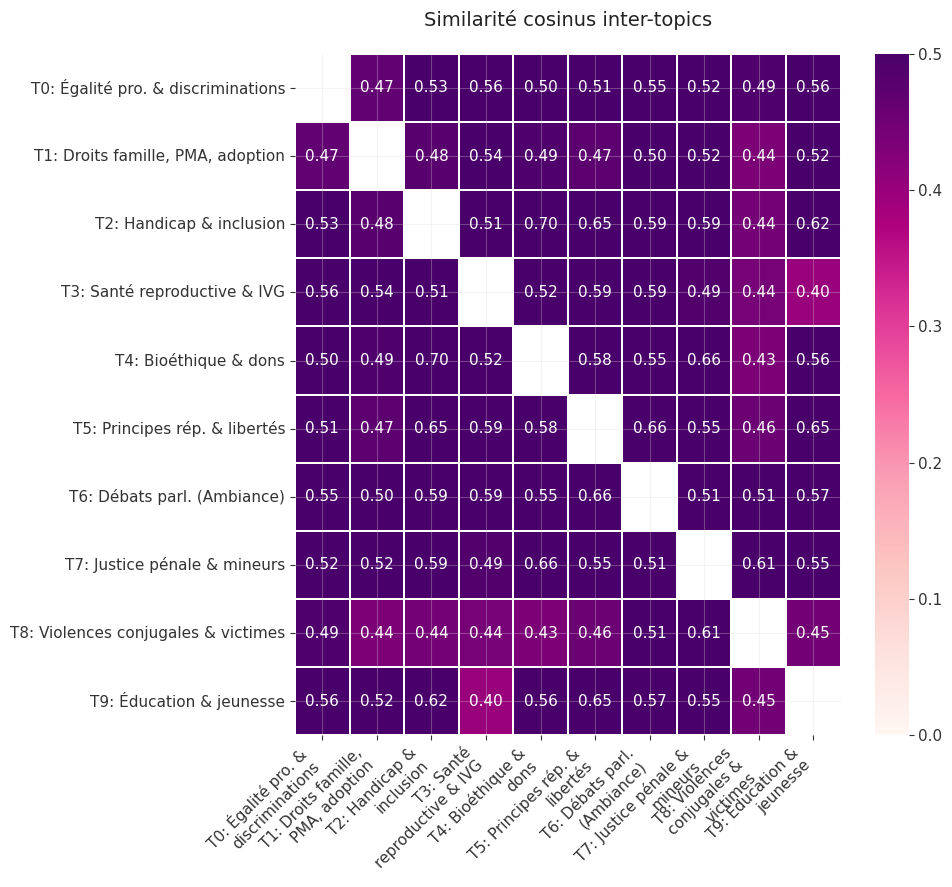

In [42]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

import textwrap

tw = lda_best.get_topics()
sim = cos_sim(tw)

labels_list = [f"T{i}: {topic_labels.get(i, '')}" for i in range(sim.shape[0])]

labels_list_x = [textwrap.fill(label, width=20) for label in labels_list]

fig, ax = plt.subplots(figsize=(10, 9))
mask = np.eye(sim.shape[0], dtype=bool)

sns.heatmap(sim, annot=True, fmt=".2f", cmap="RdPu", mask=mask, vmin=0, vmax=0.5,
            linewidths=0.3, linecolor='white',
            xticklabels=labels_list_x,  # Ajout des labels sur l'axe X
            yticklabels=labels_list,    # Ajout des labels sur l'axe Y
            ax=ax)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

ax.set_title("Similarité cosinus inter-topics", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

Inference: 100%|██████████| 7676/7676 [00:05<00:00, 1469.17it/s]


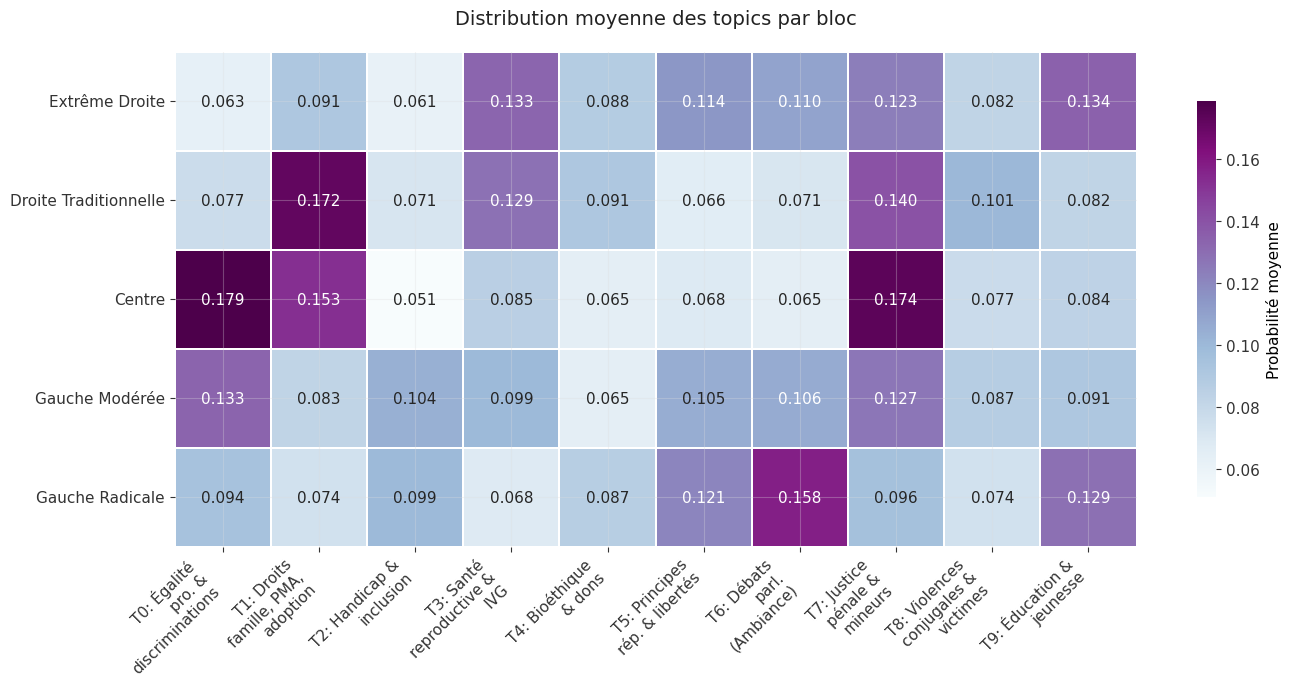

In [43]:
# Distribution par bloc
dists = []
for bow in tqdm(corpus, desc="Inference"):
    dt = lda_best.get_document_topics(bow, minimum_probability=0.0)
    probs = [0.0] * lda_best.num_topics
    for tid, p in dt: probs[tid] = p
    dists.append(probs)

tc_noms = [f"T{i}: {topic_labels[i]}" for i in range(lda_best.num_topics)]

df_topics = pd.DataFrame(dists, columns=tc_noms)
df_topics['bloc'] = df_blocs['bloc'].values[:len(df_topics)]
df_topics['date'] = df_blocs['date'].values[:len(df_topics)]

moy = df_topics.groupby('bloc')[tc_noms].mean()
moy = moy.reindex([b for b in ORDRE_BLOCS if b in moy.index])

labels_list_x = [textwrap.fill(label, width=15) for label in tc_noms]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(moy, annot=True, fmt=".3f", cmap="BuPu", linewidths=0.3, linecolor='white',
            xticklabels=labels_list_x,
            cbar_kws={'label': 'Probabilité moyenne', 'shrink': 0.8}, ax=ax)

plt.xticks(rotation=45, ha='right')
ax.set_title("Distribution moyenne des topics par bloc", fontsize=14, pad=20)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### A.8 Evolution temporelle d'un topic

Après avoir inspecté les topics, on identifie celui qui contient des termes liés
a l'immigration/identité et mettez son numéro dans `TOPIC_A_SUIVRE`.
PS : Ici le LDA n'a pas identifié de topic lié à l'immigration, on passe le code de dessous en commentaire. 

In [44]:
"""
TOPIC_A_SUIVRE = 0  
NOM_TOPIC = "Topic a identifier"

df_topics['annee'] = df_topics['date'].dt.year
col = f"topic_{TOPIC_A_SUIVRE}"
evol = df_topics.groupby(['annee', 'bloc'])[col].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
for bloc in ORDRE_BLOCS:
    s = evol[evol['bloc']==bloc].sort_values('annee')
    if s.empty: continue
    ax.plot(s['annee'], s[col], marker='o', label=bloc, color=COULEURS_BLOCS[bloc], lw=2)
ax.set_title(f"Evolution du {NOM_TOPIC} (topic #{TOPIC_A_SUIVRE}) par bloc")
ax.set_ylabel("Probabilite moyenne")
ax.set_xlabel("Annee")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()
"""

'\nTOPIC_A_SUIVRE = 0  \nNOM_TOPIC = "Topic a identifier"\n\ndf_topics[\'annee\'] = df_topics[\'date\'].dt.year\ncol = f"topic_{TOPIC_A_SUIVRE}"\nevol = df_topics.groupby([\'annee\', \'bloc\'])[col].mean().reset_index()\n\nfig, ax = plt.subplots(figsize=(11, 5))\nfor bloc in ORDRE_BLOCS:\n    s = evol[evol[\'bloc\']==bloc].sort_values(\'annee\')\n    if s.empty: continue\n    ax.plot(s[\'annee\'], s[col], marker=\'o\', label=bloc, color=COULEURS_BLOCS[bloc], lw=2)\nax.set_title(f"Evolution du {NOM_TOPIC} (topic #{TOPIC_A_SUIVRE}) par bloc")\nax.set_ylabel("Probabilite moyenne")\nax.set_xlabel("Annee")\nax.legend(bbox_to_anchor=(1.01, 1), loc=\'upper left\')\nplt.tight_layout()\nplt.show()\n'

## Partie A2 . GuidedLDA (Seeded Topic Modeling)

### Pourquoi la GuidedLDA ?

La LDA classique est **non supervisée** : elle découvre les topics sans aucune indication
de ce qu'on cherche. C'est une force (pas de biais a priori) mais aussi une limite :
si le signal "immigration/identité" est noyé dans un corpus thématiquement riche,
la LDA peut ne pas le faire émerger comme un topic distinct.

La **GuidedLDA** (Jagarlamudi, Daumé III et Udupa, 2012) est une approche **semi-supervisée** :
on fournit des **mots graines** (seed words) pour certains topics, et le modèle est "guidé"
pour faire converger ces topics vers les mots graines. Les autres topics restent libres.

Concrètement, on fournit des seed words pour un topic "immigration/identité"
(immigr, islam, étranger, cultur, frontiér, religion...) et on laisse le modèle
organiser les autres topics librement. Le paramètre `seed_confidence` controle
la force du guidage (0.15 = guidage léger, le modèle reste flexible).

Référence : Jagarlamudi, J., Daumé III, H. et Udupa, R. (2012).
Incorporating Lexical Priors into Topic Models. EACL.

In [27]:
import subprocess, sys
try:
    import guidedlda
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "guidedlda"])
    import guidedlda

from sklearn.feature_extraction.text import CountVectorizer

print("GuidedLDA importé avec succès.")

GuidedLDA importé avec succès.


### A2.1 Construction de la matrice document-terme

GuidedLDA utilise l'interface scikit-learn (matrice sparse) au lieu de gensim.
On reconstruit donc la matrice a partir des textes tokenisés.

In [28]:
# On rejoint les tokens en texte pour le CountVectorizer
textes_joins = [" ".join(doc) for doc in textes_lda]

# CountVectorizer avec le meme filtrage que gensim
vectorizer = CountVectorizer(
    max_df=0.3,    # meme seuil que no_above
    min_df=10,     # meme seuil que no_below
    max_features=5000,
)
X_dtm = vectorizer.fit_transform(textes_joins)
vocab = vectorizer.get_feature_names_out()
word2id = {w: i for i, w in enumerate(vocab)}

print(f"Matrice document-terme : {X_dtm.shape}")
print(f"Vocabulaire : {len(vocab)} termes")

Matrice document-terme : (7676, 5000)
Vocabulaire : 5000 termes


### A2.2 Définition des seed topics

On définit les mots graines pour le topic "immigration/identité".
Les autres topics sont laissés libres (pas de seed words).

Les mots sont stemmés car notre vocabulaire est stemmé.

In [29]:
# Seed words pour le topic immigration/identite (stemmés)
# On met aussi quelques seeds pour d'autres topics identifiables
# pour aider le modèle a mieux séparer les thématiques

seed_topic_list = [
    # Topic 0 : Immigration / Identité / Religion (NOTRE CIBLE)
    ["immigr", "islam", "étrang", "cultur", "fronti", "religi",
     "muslim", "clandestin", "oqtf", "expuls", "migrant", "integr",
     "communautarism", "asylum", "terroir", "voil", "identit"],

    # Topic 1 : Enfance / Protection des mineurs
    ["enfant", "mineur", "pédocrimin", "protect", "parent", "famill",
     "adopt", "gardienn", "tuteur"],

    # Topic 2 : Santé / IVG / Corps
    ["sant", "médecin", "grossess", "soignant", "hôpit", "gynécolog",
     "contracept", "clinic"],

    # Topic 3 : Justice / Pénal
    ["justic", "pénal", "tribunal", "magistrat", "condamn", "infract",
     "pein", "récidiv", "plaign"],

    # Topic 4 : Travail / Egalité professionnelle
    ["travail", "entrepris", "salar", "emploi", "professionnel",
     "carriér", "inégal", "remuner"],
]

# Construction du dictionnaire seed_topics pour GuidedLDA
seed_topics = {}
seeds_trouvees = {}
seeds_manquantes = {}

for t_id, seed_list in enumerate(seed_topic_list):
    trouvees = []
    manquantes = []
    for word in seed_list:
        if word in word2id:
            seed_topics[word2id[word]] = t_id
            trouvees.append(word)
        else:
            # Chercher des mots qui commencent par le seed (le stemming peut varier)
            matches = [w for w in vocab if w.startswith(word[:5])]
            if matches:
                for m in matches[:2]:  # prendre les 2 premiers matchs
                    seed_topics[word2id[m]] = t_id
                    trouvees.append(m)
            else:
                manquantes.append(word)

    seeds_trouvees[t_id] = trouvees
    seeds_manquantes[t_id] = manquantes

    nom = ["Immigration/Identité", "Enfance/Mineurs", "Santé/IVG", "Justice/Pénal", "Travail/Egalité"][t_id]
    print(f"Topic {t_id} ({nom}) : {len(trouvees)} seeds trouvées, {len(manquantes)} manquantes")
    if manquantes:
        print(f"  Manquantes : {manquantes}")

print(f"\nTotal : {len(seed_topics)} mots graines mappés.")

Topic 0 (Immigration/Identité) : 18 seeds trouvées, 2 manquantes
  Manquantes : ['muslim', 'asylum']
Topic 1 (Enfance/Mineurs) : 8 seeds trouvées, 1 manquantes
  Manquantes : ['tuteur']
Topic 2 (Santé/IVG) : 8 seeds trouvées, 0 manquantes
Topic 3 (Justice/Pénal) : 9 seeds trouvées, 0 manquantes
Topic 4 (Travail/Egalité) : 8 seeds trouvées, 1 manquantes
  Manquantes : ['remuner']

Total : 51 mots graines mappés.


### A2.3 Entrainement du modèle GuidedLDA

On entraine avec 10 topics (5 guidés + 5 libres) et un `seed_confidence` de 0.15
(guidage léger pour ne pas forcer artificiellement les résultats).

In [30]:
chemin_guided = os.path.join(DOSSIER_DATAFRAMES, "guided_lda_results.pkl")

if os.path.exists(chemin_guided):
    with open(chemin_guided, 'rb') as f:
        guided_results = pickle.load(f)
    topic_word = guided_results['topic_word']
    doc_topic = guided_results['doc_topic']
    print("GuidedLDA chargée depuis le cache.")
else:
    print("Entrainement GuidedLDA (10 topics, seed_confidence=0.15)...")
    print("Cela prend 2-5 minutes.\n")

    model_guided = guidedlda.GuidedLDA(
        n_topics=10,
        n_iter=200,
        random_state=42,
        refresh=50
    )
    model_guided.fit(X_dtm, seed_topics=seed_topics, seed_confidence=0.15)

    topic_word = model_guided.topic_word_
    doc_topic = model_guided.transform(X_dtm)

    guided_results = {'topic_word': topic_word, 'doc_topic': doc_topic}
    with open(chemin_guided, 'wb') as f:
        pickle.dump(guided_results, f)
    print("Sauvegardé.")

GuidedLDA chargée depuis le cache.


### A2.4 Inspection des topics GuidedLDA

In [45]:
print("=" * 80)
print("TOPICS GUIDEDLDA (10 topics, 5 guidés + 5 libres)")
print("=" * 80)

noms_topics = {
    0: "Immigration & Identité (GUIDÉ)",
    1: "Enfance, Famille & PMA (GUIDÉ)",
    2: "Santé & IVG (GUIDÉ)",
    3: "Justice pénale & Infractions (GUIDÉ)",
    4: "Travail & Égalité professionnelle (GUIDÉ)",
    5: "Éducation, École & Jeunesse (LIBRE)",
    6: "Handicap & Débats (LIBRE)",
    7: "Protection de l'enfance & Victimes (LIBRE)",
    8: "Judiciaire & Violences conjugales (LIBRE)",
    9: "Europe, Économie & International (LIBRE)"
}

n_top = 15
for t_id in range(topic_word.shape[0]):
    top_indices = np.argsort(topic_word[t_id])[::-1][:n_top]
    top_words = [(vocab[j], topic_word[t_id][j]) for j in top_indices]
    mots_str = ", ".join([f"{w} ({p:.4f})" for w, p in top_words])
    nom = noms_topics.get(t_id, f"Topic {t_id}")
    print(f"\n  Topic #{t_id:2d} [{nom}]")
    print(f"    {mots_str}")

TOPICS GUIDEDLDA (10 topics, 5 guidés + 5 libres)

  Topic # 0 [Immigration & Identité (GUIDÉ)]
    franc (0.0123), républ (0.0070), polit (0.0067), contr (0.0058), san (0.0055), autr (0.0050), pay (0.0050), libert (0.0050), quelqu (0.0049), ceux (0.0047), homm (0.0041), alor (0.0036), person (0.0036), quand (0.0035), certain (0.0034)

  Topic # 1 [Enfance, Famille & PMA (GUIDÉ)]
    enfant (0.0301), coupl (0.0104), parent (0.0099), person (0.0084), adopt (0.0080), autr (0.0076), famill (0.0069), cas (0.0064), pma (0.0060), entre (0.0057), seul (0.0055), filiat (0.0054), homm (0.0050), don (0.0050), ident (0.0040)

  Topic # 2 [Santé & IVG (GUIDÉ)]
    sant (0.0098), pratiqu (0.0077), libert (0.0074), médecin (0.0062), acces (0.0062), recour (0.0061), grossess (0.0058), elle (0.0057), del (0.0053), autr (0.0053), sag_femm (0.0052), constitu (0.0052), certain (0.0050), garant (0.0047), avort (0.0042)

  Topic # 3 [Justice pénale & Infractions (GUIDÉ)]
    mineur (0.0198), victim (0.0152

### A2.5 Distribution du topic Immigration par bloc et par année

In [46]:
# Le topic 0 est notre topic immigration/identité guidé
df_guided = pd.DataFrame({
    'poids_immigration': doc_topic[:, 0],
    'bloc': df_blocs['bloc'].values[:doc_topic.shape[0]],
    'date': df_blocs['date'].values[:doc_topic.shape[0]],
})
df_guided['annee'] = pd.to_datetime(df_guided['date']).dt.year

# Poids moyen par bloc
poids_bloc = df_guided.groupby('bloc')['poids_immigration'].mean().sort_values(ascending=False)
print("Poids moyen du topic Immigration/Identité par bloc :")
for bloc, poids in poids_bloc.items():
    print(f"  {bloc:30s} : {poids:.4f}")

Poids moyen du topic Immigration/Identité par bloc :
  Gauche Radicale                : 0.2006
  Extrême Droite                 : 0.1996
  Gauche Modérée                 : 0.1539
  Droite Traditionnelle          : 0.1054
  Centre                         : 0.0954


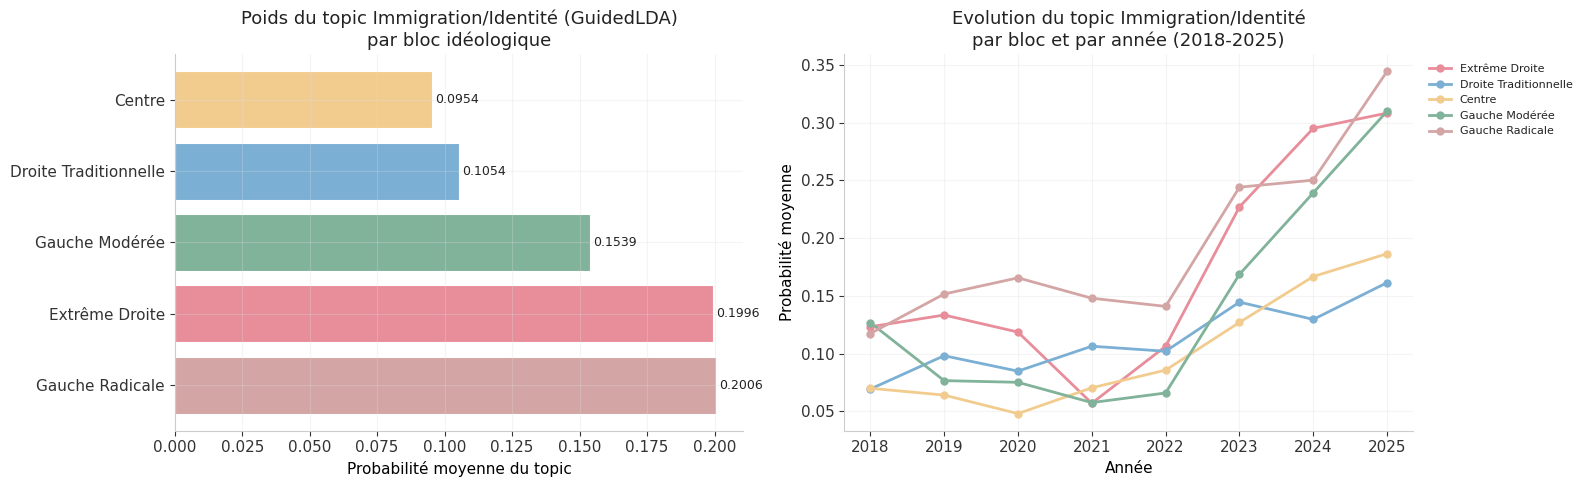

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

poids_bloc_df = poids_bloc.reset_index()
poids_bloc_df.columns = ['bloc', 'poids']
poids_bloc_df = poids_bloc_df[poids_bloc_df['bloc'].isin(ORDRE_BLOCS)]

colors = [COULEURS_BLOCS.get(b, '#DDD') for b in poids_bloc_df['bloc']]

axes[0].barh(poids_bloc_df['bloc'], poids_bloc_df['poids'], color=colors, edgecolor='white', lw=0.8)

for i, row in enumerate(poids_bloc_df.itertuples()):
    axes[0].text(row.poids + 0.001, i, f"{row.poids:.4f}", va='center', fontsize=9)

axes[0].set_xlabel("Probabilité moyenne du topic")
axes[0].set_title("Poids du topic Immigration/Identité (GuidedLDA)\npar bloc idéologique")

evol_g = df_guided.groupby(['annee', 'bloc'])['poids_immigration'].mean().reset_index()

evol_g = evol_g[(evol_g['annee'] >= 2018) & (evol_g['annee'] <= 2025)]

for bloc in ORDRE_BLOCS:
    s = evol_g[evol_g['bloc']==bloc].sort_values('annee')
    if s.empty: 
        continue
    axes[1].plot(s['annee'], s['poids_immigration'], marker='o', label=bloc,
                 color=COULEURS_BLOCS.get(bloc, '#DDD'), lw=2, markersize=5)

axes[1].set_xlabel("Année")
axes[1].set_ylabel("Probabilité moyenne")
axes[1].set_title("Evolution du topic Immigration/Identité\npar bloc et par année (2018-2025)")

axes[1].set_xticks(range(2018, 2026))

axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

### A2.6 Comparaison LDA classique vs GuidedLDA

La GuidedLDA devrait produire un topic immigration plus propre et plus interprétable
que la LDA classique. On compare les deux ci-dessous.

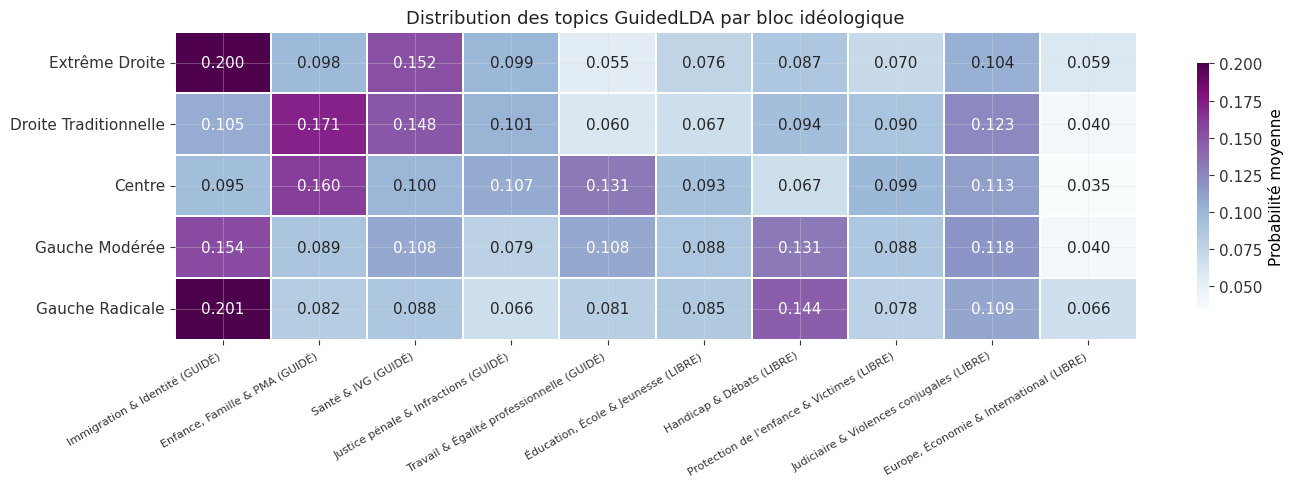

In [49]:
# Heatmap bloc x topics (GuidedLDA)
df_guided_topics = pd.DataFrame(doc_topic, columns=[f"topic_{i}" for i in range(doc_topic.shape[1])])
df_guided_topics['bloc'] = df_blocs['bloc'].values[:len(df_guided_topics)]
tc = [f"topic_{i}" for i in range(doc_topic.shape[1])]
moy_g = df_guided_topics.groupby('bloc')[tc].mean()
moy_g = moy_g.reindex([b for b in ORDRE_BLOCS if b in moy_g.index])

# Renommer les colonnes avec les noms des topics
col_names = [noms_topics.get(i, f"Topic {i}") for i in range(doc_topic.shape[1])]
moy_g.columns = col_names

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(moy_g, annot=True, fmt=".3f", cmap="BuPu", linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Probabilité moyenne', 'shrink': 0.8}, ax=ax)
ax.set_title("Distribution des topics GuidedLDA par bloc idéologique")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## Partie A3 . BERTopic (Topic Modeling neuronal)

### Pourquoi BERTopic ?

La LDA et la GuidedLDA reposent sur le **bag-of-words** : elles ignorent l'ordre des mots
et les relations syntaxiques. Pour un corpus politique ou les memes mots ("femmes", "culture",
"protection") apparaissent dans des frames opposes (feministe vs. femonationaliste),
c'est une limitation importante.

**BERTopic** (Grootendorst, 2022) resout ce probleme en combinant trois composants :

1. **Sentence embeddings** : chaque document est represente par un vecteur dense
   qui capture le sens global (ici via Sentence-CamemBERT-Large).
2. **HDBSCAN** (McInnes et al., 2017) : clustering hierarchique base sur la densite,
   qui decouvre automatiquement le nombre de clusters et tolere le bruit.
3. **c-TF-IDF** : une variante de TF-IDF calculee par cluster plutot que par document,
   qui identifie les mots les plus representatifs de chaque topic.

BERTopic est devenu la methode de reference pour le topic modeling de corpus politiques
(Mu, Bontcheva & Aletras, 2024, ACL). Son avantage principal est qu'elle preserve la
semantique contextuelle : deux occurrences du mot "protection" dans des contextes differents
(protection des femmes vs. protection des frontieres) seront correctement separees.

### A3.1 Installation et entrainement

In [ ]:
import subprocess, sys
try:
    from bertopic import BERTopic
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "bertopic"])
    from bertopic import BERTopic

from sentence_transformers import SentenceTransformer
import numpy as np

print("BERTopic importe avec succes.")

# On reutilise les embeddings Sentence-CamemBERT deja calcules
# pour eviter de re-encoder tout le corpus.
if 'vecteur' in df_blocs.columns:
    embeddings_array = np.vstack(df_blocs['vecteur'].values)
    print(f"Embeddings existants reutilises : {embeddings_array.shape}")
else:
    print("Calcul des embeddings...")
    st_model = SentenceTransformer("dangvantuan/sentence-camembert-large")
    textes = df_blocs['texte'].tolist()
    textes_tronques = [t[:1500] if len(t) > 1500 else t for t in textes]
    embeddings_array = st_model.encode(textes_tronques, batch_size=32,
                                        show_progress_bar=True, normalize_embeddings=True)

In [ ]:
# Entrainement BERTopic
# On utilise les embeddings pre-calcules (calculate_probabilities=True
# pour avoir les probabilites de topic par document)
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords francaises + bruit parlementaire
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
sw = list(stopwords.words('french')) + [
    "monsieur", "madame", "president", "presidente", "ministre",
    "depute", "amendement", "article", "projet", "loi", "texte",
    "commission", "gouvernement", "assemblee", "nationale",
    "groupe", "applaudissements", "chers", "collegues",
]

vectorizer = CountVectorizer(stop_words=sw, min_df=5, max_df=0.3)

chemin_bertopic = os.path.join(DOSSIER_DATAFRAMES, "bertopic_model")

if os.path.exists(chemin_bertopic):
    topic_model = BERTopic.load(chemin_bertopic)
    topics = topic_model.topics_
    print(f"BERTopic charge depuis le cache ({len(set(topics))} topics).")
else:
    hdbscan_model = HDBSCAN(min_cluster_size=50, min_samples=10,
                             metric='euclidean', prediction_data=True)
    topic_model = BERTopic(
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        calculate_probabilities=True,
        verbose=True
    )
    topics, probs = topic_model.fit_transform(
        df_blocs['texte'].tolist(), embeddings=embeddings_array
    )
    topic_model.save(chemin_bertopic, serialization="pickle")
    print(f"BERTopic entraine : {len(set(topics))} topics decouverts.")

### A3.2 Inspection des topics BERTopic

BERTopic produit des topics plus interpretables que la LDA car les mots representatifs
sont selectionnes par c-TF-IDF (les mots les plus specifiques a un cluster par rapport
au corpus global). Les topics sont ordonnes par taille (topic 0 = le plus frequent,
topic -1 = bruit/outliers).

In [ ]:
# Affichage des topics
topic_info = topic_model.get_topic_info()
print(f"\nNombre de topics (hors outliers) : {len(topic_info) - 1}")
print(f"Outliers (topic -1) : {(np.array(topics) == -1).sum()} documents\n")

for _, row in topic_info.head(15).iterrows():
    tid = row['Topic']
    if tid == -1:
        continue
    words = topic_model.get_topic(tid)
    words_str = ", ".join([f"{w} ({s:.3f})" for w, s in words[:10]])
    print(f"Topic {tid:3d} (n={row['Count']:4d}) : {words_str}")

### A3.3 Distribution des topics par bloc ideologique

On utilise la methode `topics_per_class` de BERTopic pour calculer la frequence relative
de chaque topic dans chaque bloc politique. C'est l'equivalent de la heatmap LDA
mais avec des topics contextualises.

In [ ]:
# Distribution par bloc
topics_per_class = topic_model.topics_per_class(
    df_blocs['texte'].tolist(),
    classes=df_blocs['bloc'].tolist()
)

# Heatmap des 10 plus gros topics par bloc
import pandas as pd

top_topics = [t for t in topic_info['Topic'].values if t != -1][:10]
pivot = topics_per_class[topics_per_class['Topic'].isin(top_topics)].pivot_table(
    index='Class', columns='Topic', values='Frequency', fill_value=0
)
# Normaliser par ligne (proportion)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)
pivot_norm = pivot_norm.reindex([b for b in ORDRE_BLOCS if b in pivot_norm.index])

# Labels des topics
col_labels = []
for t in pivot_norm.columns:
    words = topic_model.get_topic(t)
    label = ", ".join([w for w, _ in words[:3]])
    col_labels.append(f"T{t}: {label}")

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_norm, annot=True, fmt=".3f", cmap="BuPu",
            linewidths=0.3, linecolor='white',
            xticklabels=col_labels,
            cbar_kws={'label': 'Frequence relative', 'shrink': 0.8}, ax=ax)
ax.set_title("BERTopic : distribution des topics par bloc ideologique")
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

### A3.4 Recherche du signal immigration/identite dans BERTopic

On cherche si un topic lie a l'immigration ou a l'identite nationale emerge naturellement,
sans seed words (contrairement a la GuidedLDA). On utilise la methode `find_topics` de BERTopic
qui cherche les topics les plus proches d'un terme de recherche dans l'espace d'embeddings.

In [ ]:
# Recherche de topics lies a l'immigration
termes_recherche = ["immigration", "etranger", "islam", "identite", "frontiere"]
print("Topics les plus proches des termes identitaires :\n")
for terme in termes_recherche:
    try:
        similar_topics, similarities = topic_model.find_topics(terme, top_n=3)
        for t, s in zip(similar_topics, similarities):
            if t == -1:
                continue
            words = topic_model.get_topic(t)
            words_str = ", ".join([w for w, _ in words[:5]])
            print(f"  '{terme}' -> Topic {t} (sim={s:.3f}) : {words_str}")
    except Exception as e:
        print(f"  '{terme}' -> Erreur : {e}")
    print()

## Partie B . Embeddings Sentence-CamemBERT et similarité cosinus

### Pourquoi Sentence-CamemBERT et pas CamemBERT brut ?

Le problème de la version précédente venait du fait qu'on utilisait **CamemBERT-base** avec
le **vecteur CLS** pour représenter des documents entiers. Comme l'ont montré Reimers et
Gurevych (2019), les modèles BERT/CamemBERT non fine-tunés produisent des représentations
CLS qui ne sont **pas adaptées a la similarité cosinus**. Tous les documents se retrouvent
dans une region très concentrée de l'espace, d'ou les scores de ~0.99 observés.

**Sentence-CamemBERT-Large** (La Javaness, 2022) résout ce problème. C'est un CamemBERT
fine-tuné avec un réseau siamois (architecture Sentence-BERT) sur le dataset STSb francais.
Il utilise le **mean pooling** (moyenne de tous les tokens) au lieu du CLS token,
et l'espace d'embeddings résultant est spécifiquement optimisé pour que la similarité cosinus
reflète la proximité sémantique réelle.

Ce modèle est classé parmi les meilleurs pour le francais sur le benchmark MTEB-French
(Ciancone et al., 2024).

### B.1 Installation et chargement du modèle

In [35]:
import subprocess, sys

try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])
    from sentence_transformers import SentenceTransformer

try:
    import torch
    print(f"GPU disponible : {torch.cuda.is_available()}")
except:
    pass

# On utilise le modèle Sentence-CamemBERT-Large (La Javaness)
# Fine-tuné sur STSb pour la similarité cosinus
MODEL_NAME = "dangvantuan/sentence-camembert-large"
print(f"Chargement de {MODEL_NAME}...")
st_model = SentenceTransformer(MODEL_NAME)
print(f"Modèle chargé. Dimension des embeddings : {st_model.get_sentence_embedding_dimension()}")

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: dangvantuan/sentence-camembert-large
INFO:httpx:HTTP Request: HEAD https://huggingface.co/dangvantuan/sentence-camembert-large/resolve/main/modules.json "HTTP/1.1 404 Not Found"


GPU disponible : False
Chargement de dangvantuan/sentence-camembert-large...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/dangvantuan/sentence-camembert-large/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/dangvantuan/sentence-camembert-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/dangvantuan/sentence-camembert-large/1f111fd01a1c8595a4e8478775d740ab03279507/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

CamembertModel LOAD REPORT from: dangvantuan/sentence-camembert-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/dangvantuan/sentence-camembert-large/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/dangvantuan/sentence-camembert-large/1f111fd01a1c8595a4e8478775d740ab03279507/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/dangvantuan/sentence-camembert-large/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/dangvantuan/sentence-camembert-large/1f111fd01a1c8595a4e8478775d740ab03279507/tokenizer_config.json "HTTP/1.

Modèle chargé. Dimension des embeddings : 1024


### B.2 Encodage des prises de parole

Le modèle Sentence-CamemBERT encode directement une phrase ou un paragraphe en un vecteur
de 1024 dimensions, optimisé pour la similarité cosinus. On encode toutes les prises de parole
du corpus et on sauvegarde le résultat.

In [36]:
chemin_emb = "/home/onyxia/work/projet_eco_socio/df_vss_embeddings_sentence.pkl"

if os.path.exists(chemin_emb):
    df_blocs = pd.read_pickle(chemin_emb)
    print(f"Embeddings chargés depuis le cache : {len(df_blocs)} prises de parole.")
else:
    print(f"Encodage de {len(df_blocs)} prises de parole...")
    print("(Sentence-CamemBERT-Large\n")

    # On encode par batches pour la barre de progression
    textes = df_blocs['texte'].tolist()
    # Troncature des textes trop longs (le modele accepte max 512 tokens)
    # Certains discours parlementaires depassent largement cette limite.
    # On tronque a ~1500 caracteres (~400 tokens) pour rester dans les limites.
    textes_tronques = [t[:1500] if len(t) > 1500 else t for t in textes]
    print(f"   {sum(1 for t in textes if len(t) > 1500)} textes tronques (> 1500 caracteres)")

    embeddings = st_model.encode(textes_tronques, batch_size=32, show_progress_bar=True,
                                  normalize_embeddings=True)
    df_blocs['vecteur'] = list(embeddings)

    df_blocs.to_pickle(chemin_emb)
    print(f"\nSauvegardé dans {chemin_emb}")

Encodage de 7676 prises de parole...
(Sentence-CamemBERT-Large

   2576 textes tronques (> 1500 caracteres)


Batches:   0%|          | 0/240 [00:00<?, ?it/s]


Sauvegardé dans /home/onyxia/work/projet_eco_socio/df_vss_embeddings_sentence.pkl


### B.3 Similarité cosinus entre blocs et extrême droite

Pour chaque année, on calcule le **centroide** de chaque bloc (moyenne de tous les vecteurs
du bloc pour cette année), puis la similarité cosinus entre chaque centroide et celui
de l'extreme droite.

Comme les embeddings sont normalisés en L2 (norme = 1), la similarité cosinus revient
a un simple produit scalaire entre centroïdes.

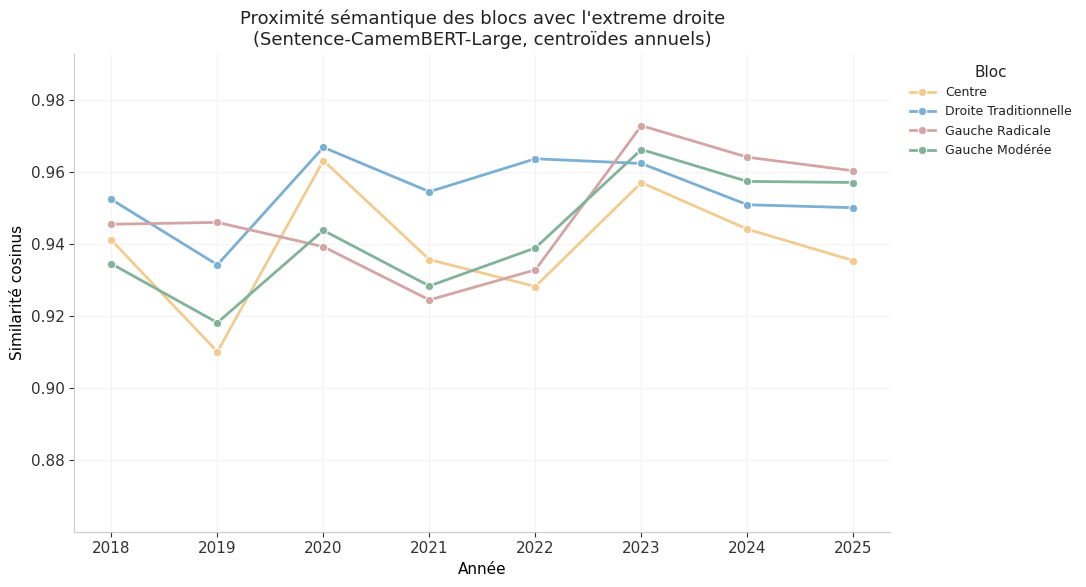


Similarités moyennes sur la période :
bloc
Droite Traditionnelle    0.954499
Gauche Radicale          0.948292
Gauche Modérée           0.943173
Centre                   0.939467


In [37]:
from sklearn.metrics.pairwise import cosine_similarity

df_blocs['annee'] = df_blocs['date'].dt.year

resultats = []
for annee in sorted(df_blocs['annee'].unique()):
    df_an = df_blocs[df_blocs['annee'] == annee]
    if "Extrême Droite" not in df_an['bloc'].values:
        continue
    vecs_ed = np.vstack(df_an[df_an['bloc']=="Extrême Droite"]['vecteur'].values)
    cent_ed = np.mean(vecs_ed, axis=0)
    for bloc in df_an['bloc'].unique():
        if bloc == "Extrême Droite": continue
        vecs = np.vstack(df_an[df_an['bloc']==bloc]['vecteur'].values)
        cent = np.mean(vecs, axis=0)
        sim = cosine_similarity([cent_ed], [cent])[0][0]
        resultats.append({'annee': annee, 'bloc': bloc, 'similarite': sim})

df_sim = pd.DataFrame(resultats)

pal = {b: COULEURS_BLOCS[b] for b in COULEURS_BLOCS if b != "Extrême Droite"}
fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=df_sim, x='annee', y='similarite', hue='bloc',
             palette=pal, marker='o', lw=2, ax=ax)
ax.set_title("Proximité sémantique des blocs avec l'extreme droite\n(Sentence-CamemBERT-Large, centroïdes annuels)")
ax.set_ylabel("Similarité cosinus")
ax.set_xlabel("Année")
ax.legend(title="Bloc", bbox_to_anchor=(1.01, 1), loc='upper left')
ylim_min = max(0, df_sim['similarite'].min() - 0.05)
ax.set_ylim(ylim_min, min(1.0, df_sim['similarite'].max() + 0.02))
plt.tight_layout()
plt.show()

print("\nSimilarités moyennes sur la période :")
print(df_sim.groupby('bloc')['similarite'].mean().sort_values(ascending=False).to_string())

### B.4 Convergence vers le concept "immigration/identite"

On encode plusieurs **phrases naturelles** representant le cadrage femonationaliste
avec le meme modele, puis on calcule le centroide de ces phrases. On mesure ensuite
comment chaque bloc politique se rapproche de ce concept au fil du temps.

> **Choix methodologique** : les sentence transformers sont optimises pour encoder
> des **phrases**, pas des listes de mots-cles. Un sac de mots comme "immigration
> clandestin frontiere etranger" produit un vecteur dans une region mal definie de
> l'espace d'embeddings. En utilisant des phrases completes qui expriment le cadrage
> femonationaliste, on obtient un centroide plus representatif du concept vise.

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

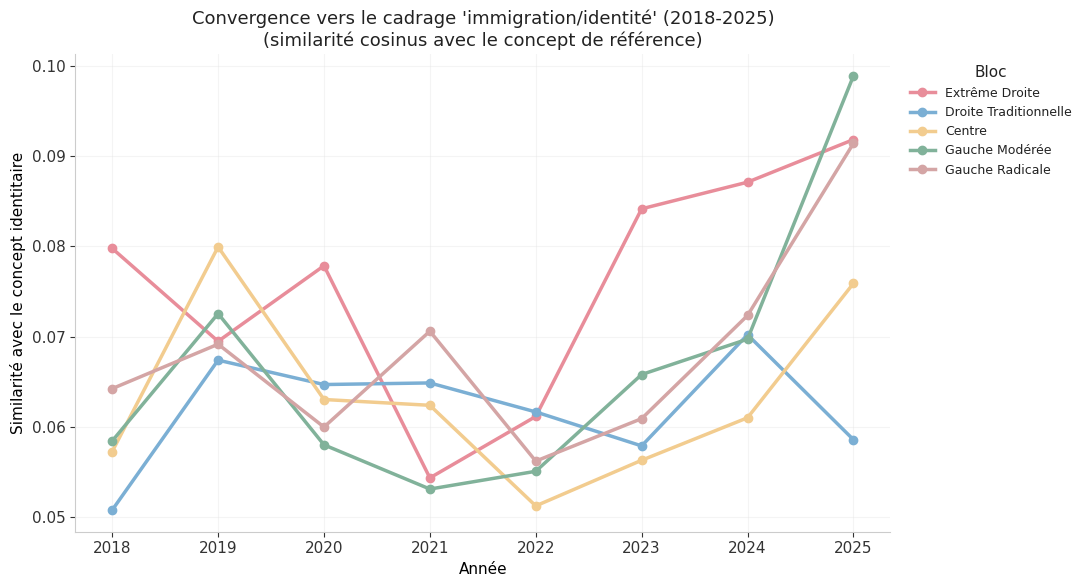


Proximité moyenne au concept identitaire (2018-2025) :
bloc
Extrême Droite           0.078150
Gauche Radicale          0.069453
Gauche Modérée           0.067973
Centre                   0.064145
Droite Traditionnelle    0.062969


In [50]:
# On encode plusieurs phrases naturelles et on moyenne leurs vecteurs,
# plutot qu'un sac de mots-cles (les sentence transformers sont optimises
# pour des phrases, pas des listes de mots).
phrases_concept = [
    "L'immigration est responsable de l'insecurite et des violences en France.",
    "Les etrangers et les musulmans menacent notre identite nationale.",
    "Il faut expulser les clandestins qui commettent des agressions.",
    "La culture d'origine de certains immigres est incompatible avec nos valeurs.",
    "Les OQTF non executees mettent en danger les femmes francaises.",
]
vecs_concept = st_model.encode(phrases_concept, normalize_embeddings=True)
vec_concept = vecs_concept.mean(axis=0)
# Normalisation L2 du centroide
vec_concept = vec_concept / (vec_concept ** 2).sum() ** 0.5

df_blocs['prox_concept'] = df_blocs['vecteur'].apply(
    lambda v: cosine_similarity([v], [vec_concept])[0][0]
)

df_blocs_filtre = df_blocs[(df_blocs['annee'] >= 2018) & (df_blocs['annee'] <= 2025)]

df_derive = df_blocs_filtre.groupby(['annee', 'bloc'])['prox_concept'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
for bloc in ORDRE_BLOCS:
    s = df_derive[df_derive['bloc']==bloc].sort_values('annee')
    if s.empty: continue
    ax.plot(s['annee'], s['prox_concept'], marker='o', label=bloc,
            color=COULEURS_BLOCS[bloc], lw=2.5, markersize=6)

ax.set_title("Convergence vers le cadrage 'immigration/identité' (2018-2025)\n(similarité cosinus avec le concept de référence)")
ax.set_ylabel("Similarité avec le concept identitaire")
ax.set_xlabel("Année")
ax.set_xticks(range(2018, 2026))
ax.legend(title="Bloc", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\nProximité moyenne au concept identitaire (2018-2025) :")
print(df_blocs_filtre.groupby('bloc')['prox_concept'].mean().sort_values(ascending=False).to_string())

### B.5 Distribution des similarités par bloc (boxplots)

Pour aller au-dela des moyennes, on regarde la **distribution** des similarités
au concept identitaire pour chaque bloc. Si l'extreme droite a non seulement
une moyenne plus élevée mais aussi une queue de distribution vers le haut,
c'est un signal plus robuste.

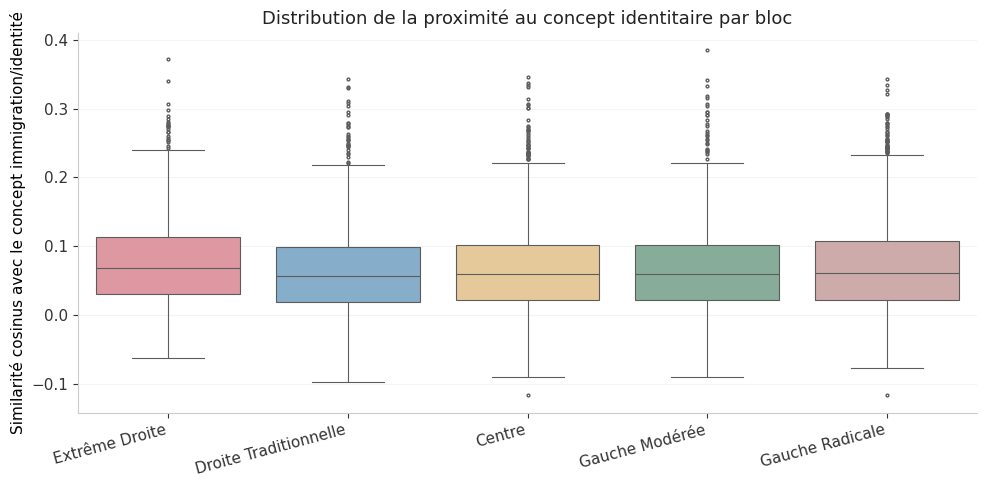

In [51]:
fig, ax = plt.subplots(figsize=(10, 5))
data_plot = df_blocs[df_blocs['bloc'].isin(ORDRE_BLOCS)].copy()
data_plot['bloc'] = pd.Categorical(data_plot['bloc'], categories=ORDRE_BLOCS, ordered=True)

sns.boxplot(data=data_plot, x='bloc', y='prox_concept',
            palette=COULEURS_BLOCS, ax=ax, fliersize=2, linewidth=0.8)
ax.set_title("Distribution de la proximité au concept identitaire par bloc")
ax.set_ylabel("Similarité cosinus avec le concept immigration/identité")
ax.set_xlabel("")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Partie C . FrameAxis : mesure bipolaire du cadrage

### Pourquoi FrameAxis ?

La similarite cosinus avec un concept unique (Partie B.4) mesure la **proximite thematique**
d'un texte avec le champ semantique immigration/identite. Mais elle ne distingue pas
la **direction** du cadrage : un texte qui accuse les immigres et un texte qui les defend
peuvent etre egalement proches du concept "immigration".

**FrameAxis** (Kwak, An & Jing, 2021) resout ce probleme en definissant un **axe bipolaire**
entre deux poles antonymiques. Chaque texte est projete sur cet axe, ce qui produit un
score signe : positif vers un pole, negatif vers l'autre.

Formellement, pour un texte represente par son vecteur embedding $v$, et deux poles
$p_{+}$ (accusateur) et $p_{-}$ (victime), le score FrameAxis est :

$$\text{score} = \cos(v, p_{+}) - \cos(v, p_{-})$$

Un score positif indique un cadrage plus proche du pole accusateur, un score negatif
un cadrage plus proche du pole victime/protecteur.

> **Avantage** : contrairement a un classifieur supervise, FrameAxis ne necessite
> aucune donnee annotee. Il fonctionne uniquement a partir de la definition
> des poles semantiques, ce qui le rend transparent et reproductible.

### C.1 Definition des poles semantiques

In [ ]:
# Pole ACCUSATEUR : phrases qui presentent l'immigration comme cause des VSS
pole_accusateur = [
    "Les immigres sont responsables des violences faites aux femmes.",
    "L'islam radical est une menace pour les droits des femmes en France.",
    "Les etrangers sous OQTF commettent des agressions sexuelles.",
    "La culture de certains migrants est incompatible avec l'egalite femmes-hommes.",
    "L'immigration incontrolee met en danger nos femmes et nos filles.",
]

# Pole VICTIME/PROTECTEUR : phrases qui presentent les immigres comme victimes
pole_victime = [
    "Les femmes immigrees sont doublement victimes de violences sexistes.",
    "Les refugiees subissent des violences sur le parcours migratoire.",
    "Il ne faut pas stigmatiser les etrangers en les associant aux violences.",
    "Les musulmans de France sont eux-memes victimes de discriminations.",
    "L'amalgame entre immigration et delinquance sexuelle est une instrumentalisation.",
]

# Encodage des poles
vecs_acc = st_model.encode(pole_accusateur, normalize_embeddings=True)
vecs_vic = st_model.encode(pole_victime, normalize_embeddings=True)

centroide_acc = vecs_acc.mean(axis=0)
centroide_acc = centroide_acc / (centroide_acc ** 2).sum() ** 0.5

centroide_vic = vecs_vic.mean(axis=0)
centroide_vic = centroide_vic / (centroide_vic ** 2).sum() ** 0.5

print(f"Similarite entre les deux poles : {cosine_similarity([centroide_acc], [centroide_vic])[0][0]:.4f}")
print("(Plus c'est bas, mieux les poles sont separes)")

### C.2 Projection des prises de parole sur l'axe

In [ ]:
# Score FrameAxis = cos(texte, pole_acc) - cos(texte, pole_vic)
from sklearn.metrics.pairwise import cosine_similarity

df_blocs['score_frameaxis'] = df_blocs['vecteur'].apply(
    lambda v: (cosine_similarity([v], [centroide_acc])[0][0]
             - cosine_similarity([v], [centroide_vic])[0][0])
)

# Score moyen par bloc
print("Score FrameAxis moyen par bloc :")
print("(positif = plus proche du pole accusateur, negatif = plus proche du pole victime)\n")
for bloc in ORDRE_BLOCS:
    sub = df_blocs[df_blocs['bloc'] == bloc]
    m = sub['score_frameaxis'].mean()
    s = sub['score_frameaxis'].std()
    n = len(sub)
    print(f"  {bloc:30s} : {m:+.4f} (std={s:.4f}, n={n})")

### C.3 Visualisation FrameAxis par bloc et evolution temporelle

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot des scores moyens par bloc
stats_fa = []
for bloc in ORDRE_BLOCS:
    sub = df_blocs[df_blocs['bloc'] == bloc]
    m = sub['score_frameaxis'].mean()
    se = sub['score_frameaxis'].sem()
    stats_fa.append({'bloc': bloc, 'mean': m, 'sem': se, 'n': len(sub)})

df_stats = pd.DataFrame(stats_fa)
colors = [COULEURS_BLOCS[b] for b in df_stats['bloc']]

axes[0].barh(df_stats['bloc'], df_stats['mean'], xerr=df_stats['sem'],
             color=colors, edgecolor='white', capsize=3, linewidth=0.8,
             error_kw={'elinewidth': 1, 'ecolor': '#999', 'capthick': 1})
axes[0].axvline(0, color='#999', lw=1)
for i, row in enumerate(df_stats.itertuples()):
    axes[0].text(row.mean + 0.002, i, f"{row.mean:+.4f}", va='center', fontsize=9)
axes[0].set_title("FrameAxis : score moyen par bloc\n(+ = accusateur, - = victime/protecteur)")
axes[0].set_xlabel("Score FrameAxis")

# Evolution temporelle
df_blocs_f = df_blocs[(df_blocs['annee'] >= 2018) & (df_blocs['annee'] <= 2025)]
evol_fa = df_blocs_f.groupby(['annee', 'bloc'])['score_frameaxis'].mean().reset_index()

for bloc in ORDRE_BLOCS:
    s = evol_fa[evol_fa['bloc'] == bloc].sort_values('annee')
    if s.empty:
        continue
    axes[1].plot(s['annee'], s['score_frameaxis'], marker='o', label=bloc,
                 color=COULEURS_BLOCS.get(bloc, '#DDD'), lw=2, markersize=5)

axes[1].axhline(0, color='#999', lw=1, ls='--')
axes[1].set_title("Evolution temporelle du score FrameAxis (2018-2025)")
axes[1].set_xlabel("Annee")
axes[1].set_ylabel("Score FrameAxis moyen")
axes[1].set_xticks(range(2018, 2026))
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Boxplot de la distribution par bloc
fig, ax = plt.subplots(figsize=(10, 5))
data_plot = df_blocs[df_blocs['bloc'].isin(ORDRE_BLOCS)].copy()
data_plot['bloc'] = pd.Categorical(data_plot['bloc'], categories=ORDRE_BLOCS, ordered=True)

sns.boxplot(data=data_plot, x='bloc', y='score_frameaxis',
            palette=COULEURS_BLOCS, ax=ax, fliersize=2, linewidth=0.8)
ax.axhline(0, color='#999', lw=1, ls='--')
ax.set_title("Distribution du score FrameAxis par bloc\n(+ = accusateur, - = victime/protecteur)")
ax.set_ylabel("Score FrameAxis")
ax.set_xlabel("")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### C.4 Interpretation du FrameAxis

Le score FrameAxis permet d'identifier :
- Les blocs dont le discours se situe **du cote accusateur** de l'axe (score positif)
- Les blocs dont le discours se situe **du cote protecteur/victime** (score negatif)
- L'**evolution temporelle** : si un bloc derive vers un pole au fil des legislatures

Contrairement a la similarite cosinus simple (Partie B), le FrameAxis capture la
**direction** du cadrage, ce qui est essentiel pour tester l'hypothese femonationaliste :
un bloc peut parler beaucoup d'immigration (forte proximite au concept) tout en defendant
les immigres (score FrameAxis negatif).

## References

- Blei, D. M., Ng, A. Y., Jordan, M. I. (2003). Latent Dirichlet Allocation. JMLR.
- Mimno, D. et al. (2011). Optimizing Semantic Coherence in Topic Models. EMNLP.
- Roder, M., Both, A., Hinneburg, A. (2015). Exploring the Space of Topic Coherence Measures. WSDM.
- McInnes, L., Healy, J., Astels, S. (2017). hdbscan: Hierarchical density based clustering. JOSS.
- Reimers, N., Gurevych, I. (2019). Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks. EMNLP.
- Martin, L. et al. (2020). CamemBERT: a Tasty French Language Model. ACL.
- Kwak, H., An, J., Jing, Y. (2021). FrameAxis: Characterizing Framing Bias and Moral Evaluation. AAAI.
- Grootendorst, M. (2022). BERTopic: Neural Topic Modeling with a Class-based TF-IDF Procedure. arXiv.
- La Javaness (2022). Sentence Embedding Fine-tuning for the French Language.
- Mu, J., Bontcheva, K., Aletras, N. (2024). LLMs Offer an Alternative to Topic Modelling. ACL.
- Ciancone, A. et al. (2024). MTEB-French: Resources for French Sentence Embedding Evaluation.